<a href="https://colab.research.google.com/github/Probin1904/PJM-Energy-Consumption-Forecasting-Pipeline/blob/main/PJM_Energy_Consumption_Forecasting_using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚡ PJM Energy Consumption Forecasting Pipeline

### 📌 Project Overview
This project builds an end-to-end machine learning pipeline to forecast hourly electricity consumption using the PJM Hourly Energy Consumption dataset. The workflow includes data preprocessing, exploratory data analysis (EDA), feature engineering, model training, model evaluation, and selection of the best-performing model. Finally, the trained model is prepared for deployment through an interactive web application.

### 🎯 Objectives
- Clean and preprocess historical energy consumption data.
- Explore consumption trends and seasonal patterns.
- Engineer time-based features for forecasting.
- Train and compare multiple machine learning models:
  - Linear Regression
  - Random Forest Regressor
  - XGBoost Regressor
- Evaluate models using MAE, RMSE, and R² Score.
- Save the best model for deployment with Hugging Face.

### 🛠️ Technologies
Python • Pandas • NumPy • Matplotlib • Scikit-learn • XGBoost • Joblib • Hugging Face

# **Phase1:Data Understanding**

In [90]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [91]:
df = pd.read_csv("/content/AEP_hourly.csv.zip")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [92]:
df.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  object 
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.9+ MB


In [94]:
df.describe()

,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


In [95]:
print("=" * 60)
print("First 5 Rows")
display(df.head())

print("=" * 60)
print("Last 5 Rows")
display(df.tail())

# Dataset shape
print("=" * 60)
print(f"Dataset Shape : {df.shape}")

# Column names
print("=" * 60)
print("Column Names:")
print(df.columns.tolist())

# Data types
print("=" * 60)
print("Data Types:")
display(df.dtypes)

# Dataset information
print("=" * 60)
print("Dataset Information:")
df.info()

# Statistical summary
print("=" * 60)
print("Statistical Summary:")
display(df.describe())

# Missing values
print("=" * 60)
print("Missing Values:")
display(df.isnull().sum())

# Duplicate values
print("=" * 60)
print(f"Duplicate Rows : {df.duplicated().sum()}")

# Unique values
print("=" * 60)
print("Unique Values:")
display(df.nunique())

First 5 Rows


,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


Last 5 Rows


,Datetime,AEP_MW
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


Dataset Shape : (121273, 2)
Column Names:
['Datetime', 'AEP_MW']
Data Types:


...

,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


Missing Values:


,0
Datetime,0
AEP_MW,0


Duplicate Rows : 0
Unique Values:


,0
Datetime,121269
AEP_MW,12643


# **Phase2:Data Cleaning and Preprocessing**

In [96]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

print("Datetime column converted successfully!")

Datetime column converted successfully!


In [97]:
df = df.sort_values("Datetime").reset_index(drop=True)

print("Dataset sorted chronologically!")

Dataset sorted chronologically!


In [98]:
df.set_index("Datetime", inplace=True)

print("Datetime column set as index!")

Datetime column set as index!


In [99]:
print("Missing Values")
print(df.isnull().sum())

print("Duplicate Rows")
print(df.duplicated().sum())

print("Dataset Shape")
print(df.shape)

print("Data Types")
print(df.dtypes)

Missing Values
AEP_MW    0
dtype: int64
Duplicate Rows
108630
Dataset Shape
(121273, 1)
Data Types
AEP_MW    float64
dtype: object


In [100]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 108630


In [101]:
print("Duplicate Index:", df.index.duplicated().sum())

Duplicate Index: 4


In [102]:
# Find duplicate timestamps
duplicate_index = df[df.index.duplicated(keep=False)]

duplicate_index

,AEP_MW
Datetime,
2014-11-02 02:00:00,12994.0
2014-11-02 02:00:00,13190.0
2015-11-01 02:00:00,10785.0
2015-11-01 02:00:00,10542.0
2016-11-06 02:00:00,10964.0
2016-11-06 02:00:00,11008.0
2017-11-05 02:00:00,10596.0
2017-11-05 02:00:00,10446.0


In [103]:
# Remove duplicate timestamps (keep first occurrence)
df = df[~df.index.duplicated(keep='first')]

print("Duplicate Index:", df.index.duplicated().sum())
print("Dataset Shape:", df.shape)

Duplicate Index: 0
Dataset Shape: (121269, 1)


In [104]:
display(df.head())

display(df.tail())

,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


,AEP_MW
Datetime,
2018-08-02 20:00:00,17673.0
2018-08-02 21:00:00,17303.0
2018-08-02 22:00:00,17001.0
2018-08-02 23:00:00,15964.0
2018-08-03 00:00:00,14809.0


# **Phase3:Exploratory Data Analysis**

In [105]:
eda_df = df.copy()
print("EDA DataFrame Created Successfully!")

EDA DataFrame Created Successfully!


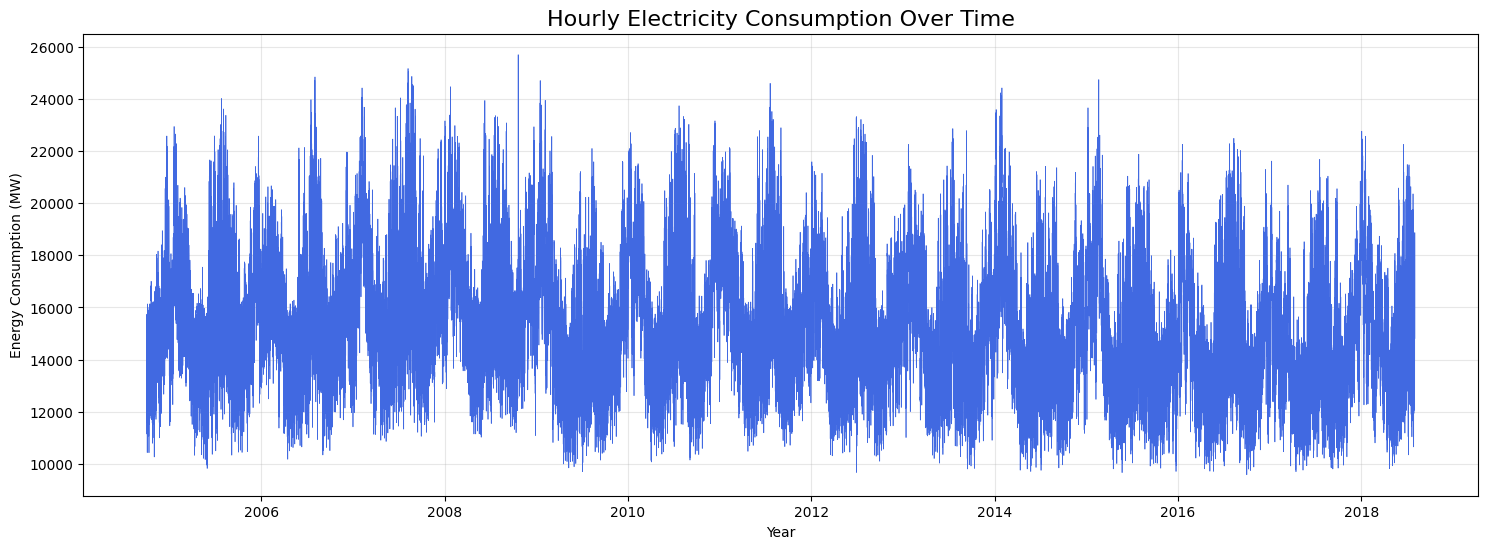

In [106]:
# Electricity Consumption Over Time

plt.figure(figsize=(18,6))

plt.plot(
    eda_df.index,
    eda_df["AEP_MW"],
    color="royalblue",
    linewidth=0.5
)

plt.title("Hourly Electricity Consumption Over Time", fontsize=16)

plt.xlabel("Year")

plt.ylabel("Energy Consumption (MW)")

plt.grid(alpha=0.3)

plt.show()

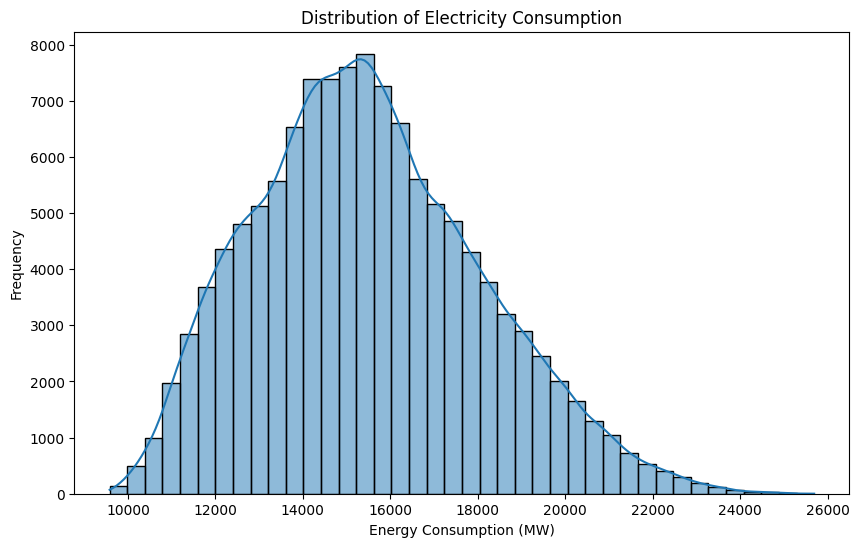

In [107]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df["AEP_MW"], bins=40, kde=True)

plt.title("Distribution of Electricity Consumption")
plt.xlabel("Energy Consumption (MW)")
plt.ylabel("Frequency")

plt.show()

# **Phase4:Feature Engineering**

In [115]:
# Time-Based Feature Engineering

feature_df = df.copy()

feature_df["Hour"] = feature_df.index.hour
feature_df["Day"] = feature_df.index.day
feature_df["Month"] = feature_df.index.month
feature_df["Year"] = feature_df.index.year
feature_df["DayOfWeek"] = feature_df.index.dayofweek
feature_df["Quarter"] = feature_df.index.quarter

# Weekend Indicator
feature_df["IsWeekend"] = feature_df["DayOfWeek"].isin([5, 6]).astype(int)

print("Time-based features created successfully!")

Time-based features created successfully!


In [109]:
feature_df.head()

,AEP_MW,Hour,Day,Month,Year,DayOfWeek,Quarter,IsWeekend
Datetime,,,,,,,,
2004-10-01 01:00:00,12379.0,1,1,10,2004,4,4,0
2004-10-01 02:00:00,11935.0,2,1,10,2004,4,4,0
2004-10-01 03:00:00,11692.0,3,1,10,2004,4,4,0
2004-10-01 04:00:00,11597.0,4,1,10,2004,4,4,0
2004-10-01 05:00:00,11681.0,5,1,10,2004,4,4,0


In [110]:
feature_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 121269 entries, 2004-10-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   AEP_MW     121269 non-null  float64
 1   Hour       121269 non-null  int32  
 2   Day        121269 non-null  int32  
 3   Month      121269 non-null  int32  
 4   Year       121269 non-null  int32  
 5   DayOfWeek  121269 non-null  int32  
 6   Quarter    121269 non-null  int32  
 7   IsWeekend  121269 non-null  int64  
dtypes: float64(1), int32(6), int64(1)
memory usage: 9.6 MB


In [111]:
feature_df.isnull().sum()

,0
AEP_MW,0
Hour,0
Day,0
Month,0
Year,0
DayOfWeek,0
Quarter,0
IsWeekend,0


# **Phase5:Model Training**

# Overview

In this phase, we train multiple machine learning models to forecast hourly electricity consumption.

Since this is a time-series forecasting problem, the dataset is split chronologically to prevent data leakage. The models are trained on historical observations and evaluated on future observations.

### Models

- Linear Regression (Baseline)
- Random Forest Regressor
- XGBoost Regressor

In [112]:
# Select Features and Target Variable

X = feature_df.drop(columns=["AEP_MW"])
y = feature_df["AEP_MW"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (121269, 7)
Target Shape  : (121269,)


In [113]:
# Chronological Train-Test Split

split_index = int(len(feature_df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

Training Samples : 97015
Testing Samples  : 24254


In [114]:
lr = LinearRegression()
lr.fit(X_train, y_train)

print("Linear Regression Trained")

Linear Regression Trained


In [76]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("Random Forest Trained")

Random Forest Trained


In [77]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    random_state=42
)
xgb.fit(X_train, y_train)
print("XGBoost Trained")

XGBoost Trained


In [78]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

print("Predictions Generated")

Predictions Generated


# **Phase6:Model Evaluation**

In [79]:
# Import Evaluation Metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
print("Evaluation Metrices imported")

Evaluation Metrices imported


In [80]:
# Model Evaluation Function

def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R² Score": round(r2, 4)
    }

In [81]:
# Evaluate Models

results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    )
)

In [82]:
# Model Comparison

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R² Score
0,Linear Regression,1759.33,2159.28,0.2194
1,Random Forest,1461.11,1972.89,0.3484
2,XGBoost,1429.24,1914.15,0.3866


In [83]:
# Best Model Selection

best_model = results_df.sort_values(
    by="R² Score",
    ascending=False
).iloc[0]

print("Best Model")
print(best_model)

Best Model
Model       XGBoost
MAE         1429.24
RMSE        1914.15
R² Score     0.3866
Name: 2, dtype: object


In [116]:
X_test

,Hour,Day,Month,Year,DayOfWeek,Quarter,IsWeekend
Datetime,,,,,,,
2015-10-27 08:00:00,8,27,10,2015,1,4,0
2015-10-27 09:00:00,9,27,10,2015,1,4,0
2015-10-27 10:00:00,10,27,10,2015,1,4,0
2015-10-27 11:00:00,11,27,10,2015,1,4,0
2015-10-27 12:00:00,12,27,10,2015,1,4,0
...,...,...,...,...,...,...,...
2018-08-02 20:00:00,20,2,8,2018,3,3,0
2018-08-02 21:00:00,21,2,8,2018,3,3,0
2018-08-02 22:00:00,22,2,8,2018,3,3,0


In [119]:
y_pred = xgb.predict(X_test)

In [120]:
y_pred

array([14888.575, 14937.799, 14638.869, ..., 17176.824, 15987.706,
       14607.345], dtype=float32)

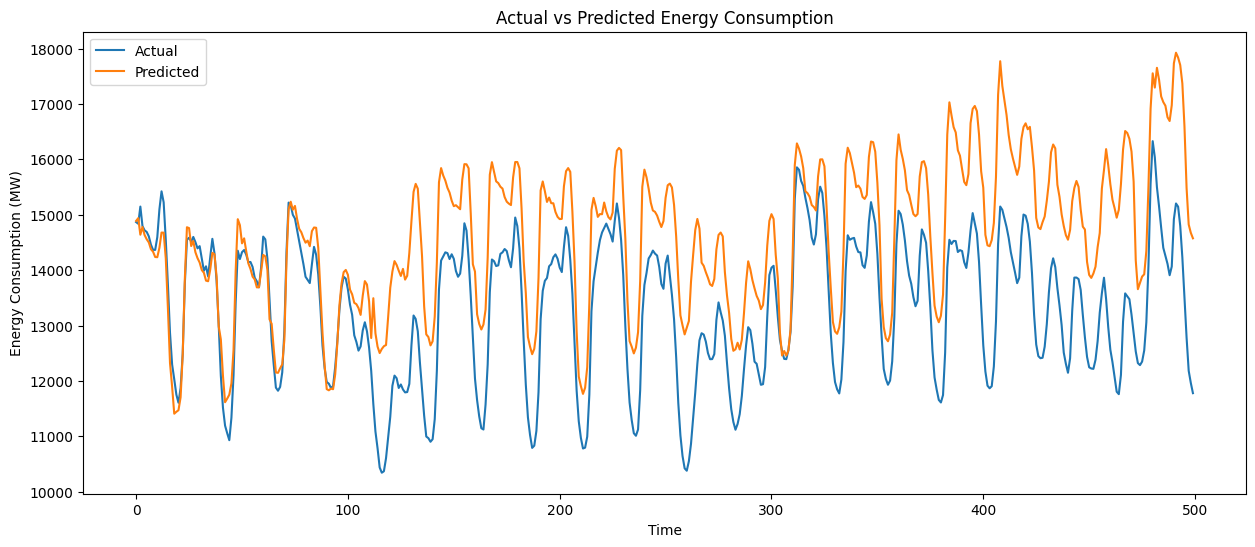

In [121]:
plt.figure(figsize=(15,6))

plt.plot(y_test.values[:500], label="Actual")
plt.plot(y_pred[:500], label="Predicted")

plt.title("Actual vs Predicted Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Energy Consumption (MW)")
plt.legend()

plt.show()

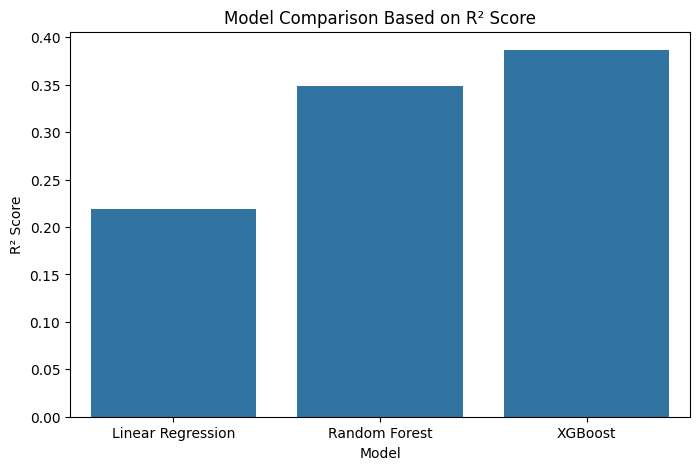

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R² Score"
)

plt.title("Model Comparison Based on R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.show()

# **Phase7:Feature Importance Analysis**

In [85]:
#Random Forest Feature Importance

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)
rf_importance

,Feature,Importance
0,Hour,0.342879
2,Month,0.273472
1,Day,0.133899
3,Year,0.117836
4,DayOfWeek,0.072333
6,IsWeekend,0.045150
5,Quarter,0.014432


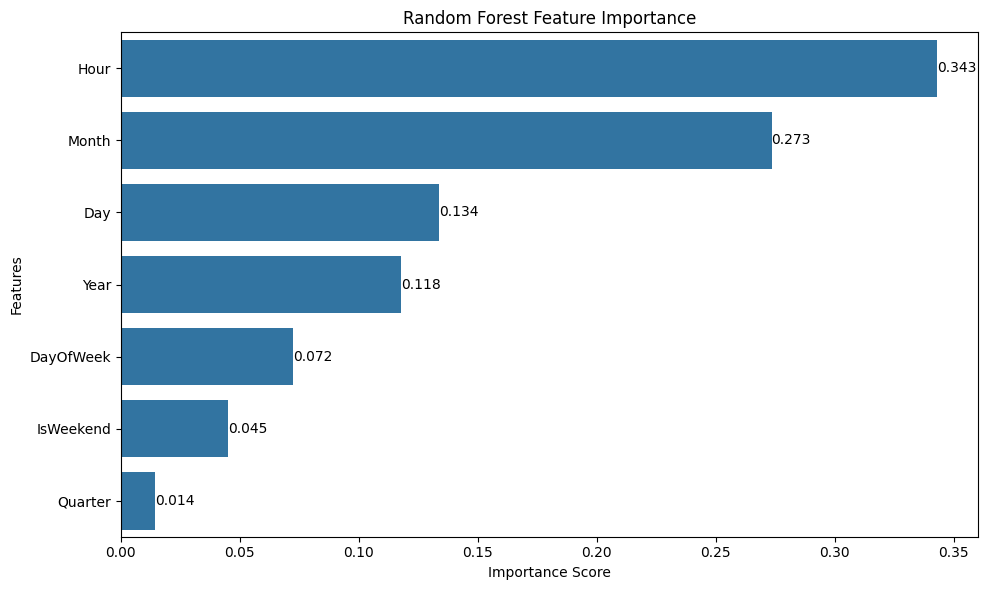

In [86]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [87]:
# XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance

,Feature,Importance
0,Hour,0.406034
2,Month,0.276557
4,DayOfWeek,0.175787
3,Year,0.083736
1,Day,0.057886
5,Quarter,0.000000
6,IsWeekend,0.000000


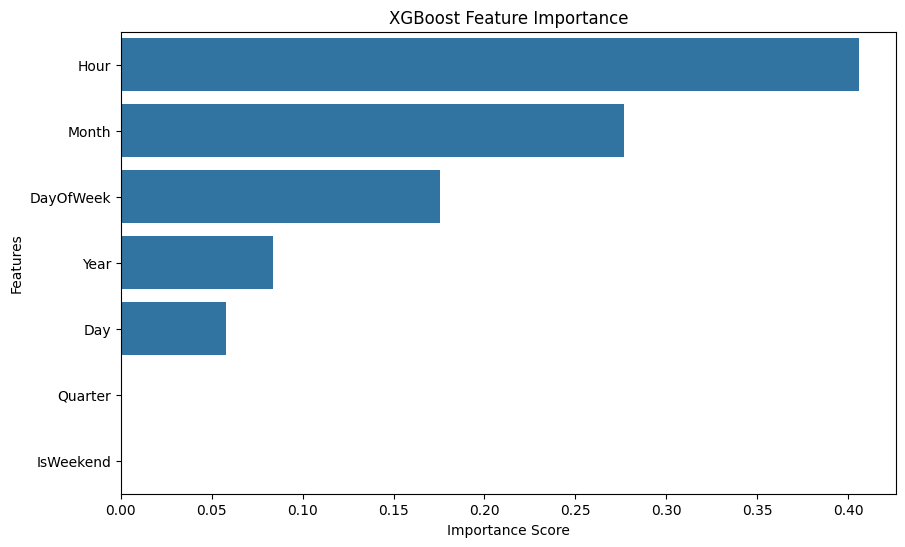

In [88]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=xgb_importance,
    x="Importance",
    y="Feature"
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

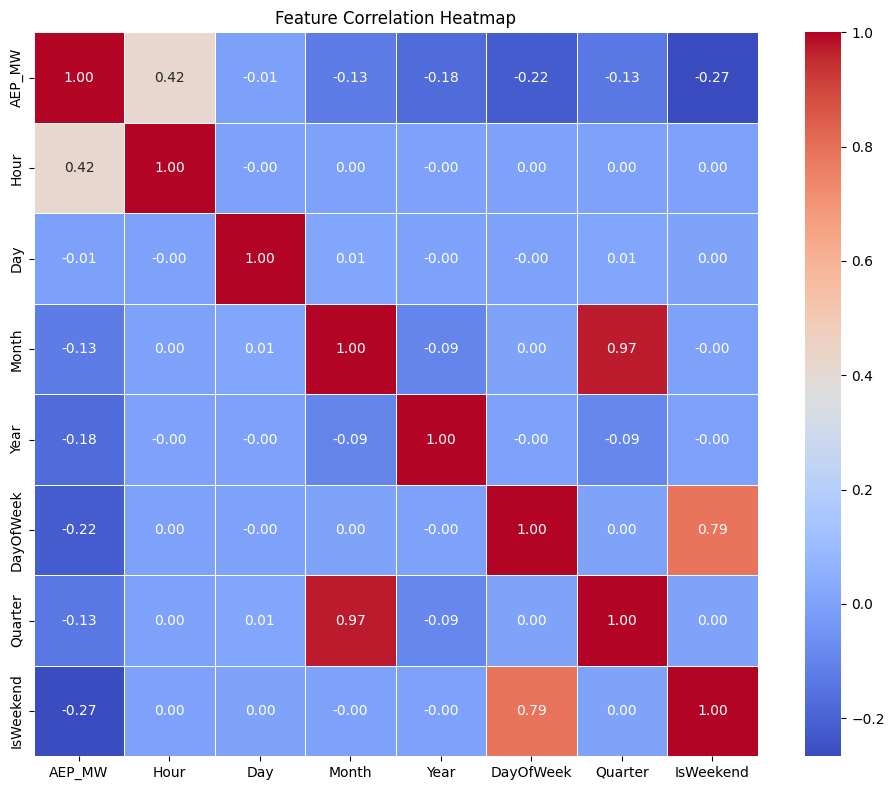

In [89]:
# ===============================================
# Feature Correlation Heatmap
# ===============================================

plt.figure(figsize=(10, 8))

correlation_matrix = feature_df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()